# Atividade Avaliativa 3 : Classificação 
## Objetivo: Classificar risco de saúde mental em baixo, médio ou alto

- Disciplina: Machine Learning
- Professor: Josenildo Costa da Silva
- Aluno: Rudney Gabriel Gonçalves Fonseca
- Matrícula: 20231SI0025

link do dataset: https://www.kaggle.com/datasets/algozee/mental-health-disorder-risk-assessment-dataset

## Etapa 2.1

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df_mental = pd.read_csv("mental_health.csv")

df_mental.head()
pd.set_option('display.max_columns', None)


In [25]:
df_mental.sample(15)

,age,gender,marital_status,education_level,employment_status,sleep_hours,physical_activity_hours_per_week,screen_time_hours_per_day,social_support_score,work_stress_level,academic_pressure_level,job_satisfaction_score,financial_stress_level,working_hours_per_week,anxiety_score,depression_score,stress_level,mood_swings_frequency,concentration_difficulty_level,panic_attack_history,family_history_mental_illness,previous_mental_health_diagnosis,therapy_history,substance_use,mental_health_risk
7807,36,Other,Single,Master,Student,3.6,10.4,9.0,8,6,10,3,8,41,3,2,3,5,8,1,0,0,1,0,1
5754,47,Female,Married,Bachelor,Employed,6.1,12.9,4.0,5,2,4,4,4,31,8,6,9,10,1,0,1,0,0,1,0
15532,59,Other,Single,High School,Self-Employed,4.7,13.5,2.2,1,8,1,10,5,52,10,8,5,7,5,0,0,1,0,0,2
19248,36,Other,Divorced,Bachelor,Self-Employed,9.6,3.6,7.4,5,10,1,5,8,53,6,8,4,6,10,1,1,0,1,1,2
22020,60,Male,Divorced,PhD,Employed,5.1,0.1,3.2,4,4,6,10,4,37,8,2,3,6,2,0,0,1,1,0,0
4960,44,Other,Divorced,PhD,Unemployed,3.7,8.5,6.3,1,4,1,5,7,32,2,2,7,2,2,0,1,1,0,0,1
19776,20,Male,Divorced,Bachelor,Student,6.8,4.5,9.1,9,7,4,9,2,51,4,10,2,7,5,0,1,0,1,1,0
1852,59,Female,Divorced,Master,Employed,9.3,11.9,10.0,10,3,2,7,10,62,9,1,7,1,5,0,0,1,1,0,0
4231,58,Male,Divorced,Bachelor,Student,4.3,7.7,1.9,2,2,6,6,5,39,3,7,3,7,2,0,1,1,1,1,1
4055,54,Other,Divorced,High School,Self-Employed,3.3,8.4,7.9,10,5,10,9,1,62,7,10,6,10,4,0,1,0,1,1,1


In [26]:
df_mental.info()

<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 25 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   age                               25000 non-null  int64  
 1   gender                            25000 non-null  str    
 2   marital_status                    25000 non-null  str    
 3   education_level                   25000 non-null  str    
 4   employment_status                 25000 non-null  str    
 5   sleep_hours                       25000 non-null  float64
 6   physical_activity_hours_per_week  25000 non-null  float64
 7   screen_time_hours_per_day         25000 non-null  float64
 8   social_support_score              25000 non-null  int64  
 9   work_stress_level                 25000 non-null  int64  
 10  academic_pressure_level           25000 non-null  int64  
 11  job_satisfaction_score            25000 non-null  int64  
 12  financial_stres

Não havia problemas com valores ausentes ou anômalos no dataset

In [27]:
df_mental.describe()

,age,sleep_hours,physical_activity_hours_per_week,screen_time_hours_per_day,social_support_score,work_stress_level,academic_pressure_level,job_satisfaction_score,financial_stress_level,working_hours_per_week,anxiety_score,depression_score,stress_level,mood_swings_frequency,concentration_difficulty_level,panic_attack_history,family_history_mental_illness,previous_mental_health_diagnosis,therapy_history,substance_use,mental_health_risk
count,25000.000000,25000.000000,25000.000000,25000.000000,25000.00000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000
mean,39.072560,6.509516,7.515400,6.469132,5.50840,5.517080,5.445880,5.471040,5.495080,45.049600,5.514000,5.534000,5.520480,5.512880,5.488240,0.497840,0.504280,0.504160,0.501640,0.499120,0.778520
std,12.404948,2.015586,4.324346,3.167682,2.88694,2.864548,2.864479,2.867816,2.881636,14.683297,2.865752,2.870048,2.873213,2.870596,2.873178,0.500005,0.499992,0.499993,0.500007,0.500009,0.691409
min,18.000000,3.000000,0.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28.000000,4.800000,3.800000,3.700000,3.00000,3.000000,3.000000,3.000000,3.000000,32.000000,3.000000,3.000000,3.000000,3.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,39.000000,6.500000,7.500000,6.500000,5.00000,6.000000,5.000000,5.000000,5.000000,45.000000,6.000000,6.000000,6.000000,6.000000,5.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000
75%,50.000000,8.200000,11.300000,9.200000,8.00000,8.000000,8.000000,8.000000,8.000000,58.000000,8.000000,8.000000,8.000000,8.000000,8.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,60.000000,10.000000,15.000000,12.000000,10.00000,10.000000,10.000000,10.000000,10.000000,70.000000,10.000000,10.000000,10.000000,10.000000,10.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000


As classes do tipo string não possuiam nenhum defeito com relação aos seus valores únicos

In [28]:
print(df_mental.gender.unique(),"\n")
print(df_mental.marital_status.unique(),"\n")
print(df_mental.education_level.unique(),"\n")
print(df_mental.employment_status.unique(),"\n")

<ArrowStringArray>
['Other', 'Male', 'Female']
Length: 3, dtype: str 

<ArrowStringArray>
['Single', 'Divorced', 'Married']
Length: 3, dtype: str 

<ArrowStringArray>
['Bachelor', 'High School', 'Master', 'PhD']
Length: 4, dtype: str 

<ArrowStringArray>
['Unemployed', 'Student', 'Employed', 'Self-Employed']
Length: 4, dtype: str 



Codificando o nível de escolaridade com ordinal coding

In [29]:
df_mental_copy = df_mental.copy()

mapa_escolaridade = {
    'High School': 1,
    'Bachelor': 2,
    'Master': 3,
    'PhD': 4
}

df_mental_copy['education_level']=df_mental_copy['education_level'].map(mapa_escolaridade)

Os atributos com maior correlação com a variavel alvo são: panic_history_attack, depression_score, anxiety_score e family_history_mental_illness

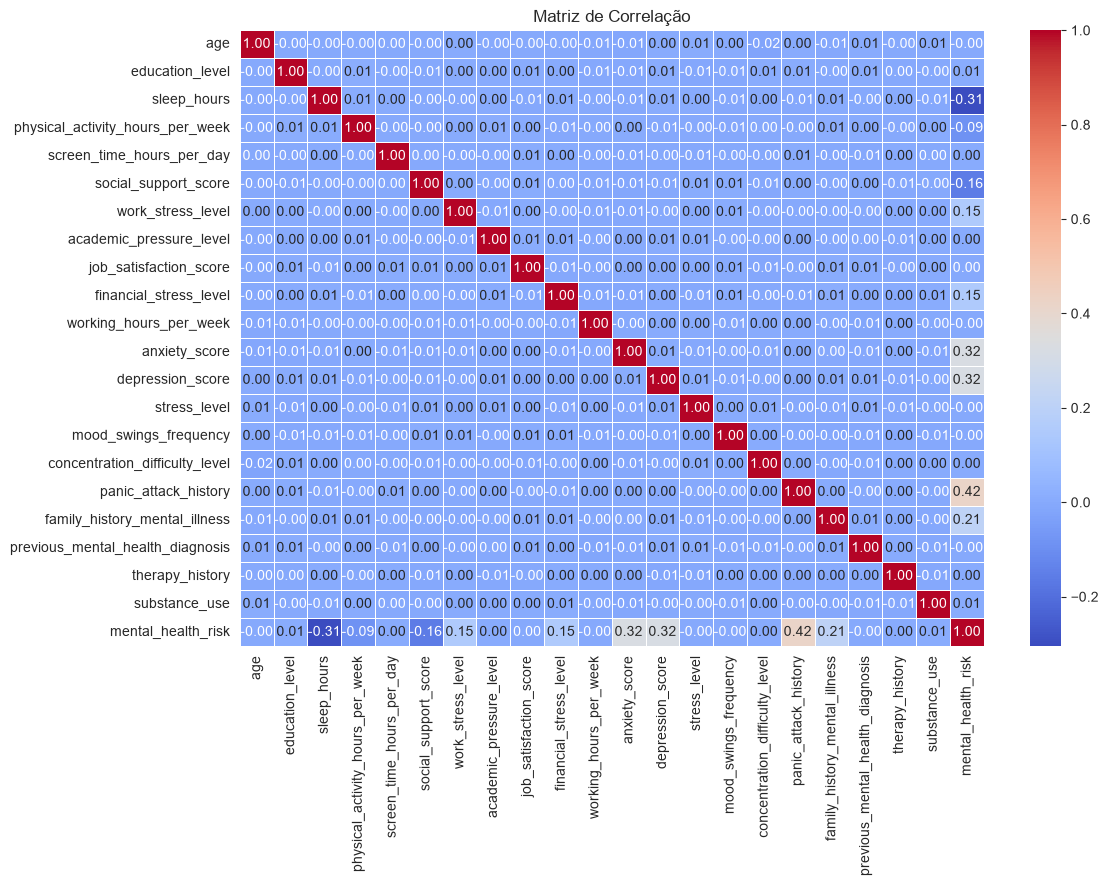

In [30]:
plt.figure(figsize=(12, 8))
corr = df_mental_copy.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
title = "Matriz de Correlação"
plt.title(title)
plt.show()

Testes feitos entre as variáveis que possuíam as melhores correlações com mental_health risk a fim de achar uma fronteira de seperação entre as classes. Delimitação encontrada com relação à classe de alto risco.

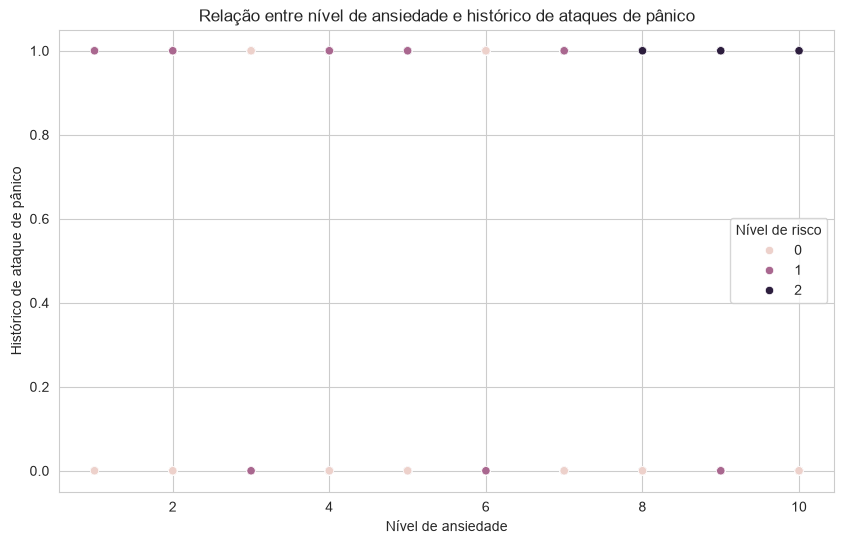

In [31]:

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_mental, x='anxiety_score', y='panic_attack_history', hue='mental_health_risk')
plt.title('Relação entre nível de ansiedade e histórico de ataques de pânico')
plt.xlabel('Nível de ansiedade')
plt.ylabel('Histórico de ataque de pânico')
plt.legend(title='Nível de risco')
plt.show()

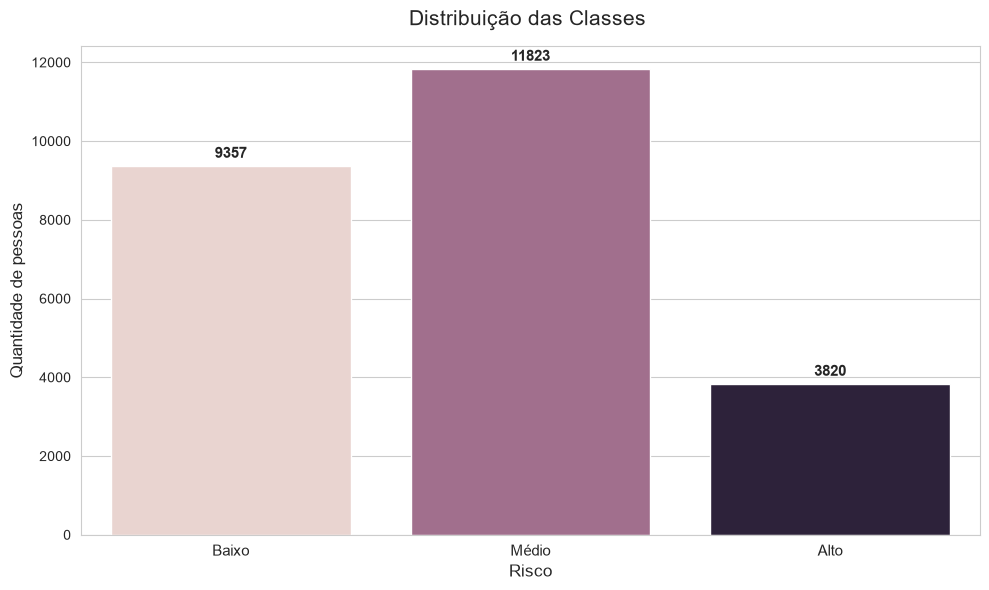

In [32]:
classes = [0,1,2]

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

ax = sns.countplot(data=df_mental, x='mental_health_risk', order=classes, hue='mental_health_risk', legend=False)

plt.title('Distribuição das Classes ', fontsize=15, pad=15)
plt.xlabel('Risco', fontsize=12)
plt.ylabel('Quantidade de pessoas', fontsize=12)

plt.xticks(ticks=[0, 1, 2], labels=['Baixo', 'Médio', 'Alto'], fontsize=11)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points',
                fontsize=11,
                fontweight='bold')

plt.tight_layout()
plt.show()

In [33]:
from sklearn.model_selection import train_test_split


df_codificado= pd.get_dummies(df_mental_copy, drop_first=True)

X = df_codificado.drop(columns=['mental_health_risk'])
y = df_codificado['mental_health_risk']

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.3, 
    random_state=777,
    stratify=y
)

## Etapa 2.2

In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score, roc_auc_score

modelo_lr = LogisticRegression(max_iter=5000)
modelo_lr.fit(X_train, y_train)

y_pred = modelo_lr.predict(X_test)
y_probs = modelo_lr.predict_proba(X_test)

acuracia      = accuracy_score(y_test, y_pred)
precisao      = precision_score(y_test, y_pred, average='weighted')
sensibilidade = recall_score(y_test, y_pred, average='weighted')
f1            = f1_score(y_test, y_pred, average='weighted')

auc_rl= roc_auc_score(y_test, y_probs, multi_class='ovr', average='weighted')

print("=== Métricas de Desempenho do modelo 'baseline' (Regressão Logística) ===")
print(f"Acurácia:      {acuracia:.4f}")
print(f"Precisão:      {precisao:.4f}")
print(f"Sensibilidade: {sensibilidade:.4f}")
print(f"F1-Score:      {f1:.4f}")
print(f"AUC:     {auc_rl:.4f}")

=== Métricas de Desempenho do modelo 'baseline' (Regressão Logística) ===
Acurácia:      0.7431
Precisão:      0.7451
Sensibilidade: 0.7431
F1-Score:      0.7426
AUC:     0.8705


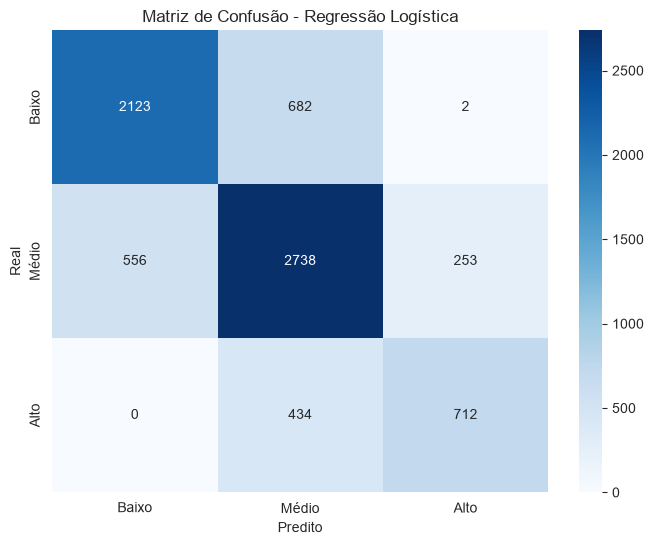

In [35]:
cm = confusion_matrix(y_test, y_pred)
labels = ["Baixo", "Médio", "Alto"]

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=labels, yticklabels=labels)
plt.title('Matriz de Confusão - Regressão Logística')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.show()

In [36]:
coefs = modelo_lr.coef_
classes = modelo_lr.classes_  

print("Coeficientes do modelo:")

for i, classe in enumerate(classes):
    print(f"\nClasse '{classe}':")
    for feature, coef in zip(X.columns, coefs[i]):
        print(f"  {feature}: {coef:.4f}")

Coeficientes do modelo:

Classe '0':
  age: -0.0003
  education_level: -0.0052
  sleep_hours: 0.5755
  physical_activity_hours_per_week: 0.0784
  screen_time_hours_per_day: -0.0062
  social_support_score: 0.2012
  work_stress_level: -0.2076
  academic_pressure_level: -0.0002
  job_satisfaction_score: -0.0040
  financial_stress_level: -0.2165
  working_hours_per_week: 0.0008
  anxiety_score: -0.4274
  depression_score: -0.4248
  stress_level: -0.0052
  mood_swings_frequency: 0.0054
  concentration_difficulty_level: -0.0075
  panic_attack_history: -3.0449
  family_history_mental_illness: -1.6085
  previous_mental_health_diagnosis: 0.0925
  therapy_history: 0.0233
  substance_use: -0.0527
  gender_Male: 0.0068
  gender_Other: -0.0064
  marital_status_Married: -0.0347
  marital_status_Single: -0.0691
  employment_status_Self-Employed: 0.0059
  employment_status_Student: -0.0028
  employment_status_Unemployed: -0.0653

Classe '1':
  age: -0.0008
  education_level: 0.0059
  sleep_hours: 0.07

Por meio deste da Regressão Logística foram obtidas algumas noções a mais sobre os atributos presentes no dataset e estabeleceu-se um objetivo de obter um modelo que ultrapasse os 74% de acurácia e, principalmente, reduza as falhas quanto a discernir a classe de alto rísco das demais.

## Etapa 2.3

O conjunto dos 8 atributos escolhidos no código abaixo foram capazes de satisfazer as expectativas do autor deste trabalho 

In [37]:
from sklearn.model_selection import train_test_split

df_codificado = df_mental_copy.copy()

Atributos = [
    'sleep_hours', 'depression_score', 'panic_attack_history',
    'anxiety_score', 'family_history_mental_illness', 'social_support_score',
    'financial_stress_level', 'work_stress_level'
]

X = df_codificado[Atributos]
                    
y = df_codificado['mental_health_risk']

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.3, 
    random_state=777,
    stratify=y
)

In [38]:

modelo_lr_2 = LogisticRegression(max_iter=5000)
modelo_lr_2.fit(X_train, y_train)

y_pred = modelo_lr_2.predict(X_test)
y_probs = modelo_lr_2.predict_proba(X_test)

acuracia      = accuracy_score(y_test, y_pred)
precisao      = precision_score(y_test, y_pred, average='weighted')
sensibilidade = recall_score(y_test, y_pred, average='weighted')
f1            = f1_score(y_test, y_pred, average='weighted')

auc_rl= roc_auc_score(y_test, y_probs, multi_class='ovr', average='weighted')

print("=== Métricas de Desempenho do modelo 'baseline' (Regressão Logística) ===")
print(f"Acurácia:      {acuracia:.4f}")
print(f"Precisão:      {precisao:.4f}")
print(f"Sensibilidade: {sensibilidade:.4f}")
print(f"F1-Score:      {f1:.4f}")
print(f"AUC:     {auc_rl:.4f}")

=== Métricas de Desempenho do modelo 'baseline' (Regressão Logística) ===
Acurácia:      0.7367
Precisão:      0.7385
Sensibilidade: 0.7367
F1-Score:      0.7360
AUC:     0.8683


A árvore sofreu de overffiting antes do ajustes feitos nos seus hiperparâmetros 

=== Métricas de Desempenho - Árvore de decisão === 
Acurácia:      0.9621
Precisão:      0.9630
Sensibilidade: 0.9621
F1-Score:      0.9618
AUC:     0.9901


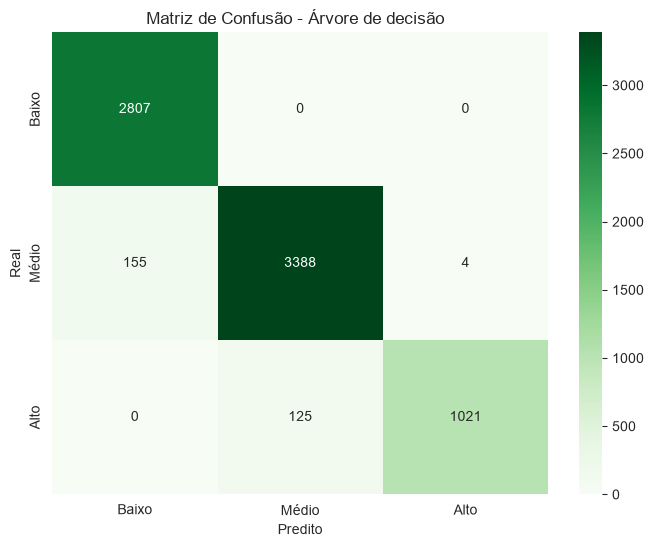

In [39]:
from sklearn.tree import DecisionTreeClassifier

modelo_dt = DecisionTreeClassifier(
    max_depth=8,                
    min_samples_split=20,       
    min_samples_leaf=10,           
    random_state=777
)
modelo_dt.fit(X_train, y_train)

y_pred_dt = modelo_dt.predict(X_test)
y_probs_dt = modelo_dt.predict_proba(X_test)

acuracia_dt      = accuracy_score(y_test, y_pred_dt)
precisao_dt      = precision_score(y_test, y_pred_dt, average='weighted')
sensibilidade_dt = recall_score(y_test, y_pred_dt, average='weighted')
f1_dt            = f1_score(y_test, y_pred_dt, average='weighted')
auc_dt     = roc_auc_score(y_test, y_probs_dt, multi_class='ovr', average='weighted')

print("=== Métricas de Desempenho - Árvore de decisão === ")
print(f"Acurácia:      {acuracia_dt:.4f}")
print(f"Precisão:      {precisao_dt:.4f}")
print(f"Sensibilidade: {sensibilidade_dt:.4f}")
print(f"F1-Score:      {f1_dt:.4f}")
print(f"AUC:     {auc_dt:.4f}")


cm_dt = confusion_matrix(y_test, y_pred_dt)
labels = ["Baixo", "Médio", "Alto"]

plt.figure(figsize=(8, 6))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens', 
            xticklabels=labels, yticklabels=labels)
plt.title('Matriz de Confusão - Árvore de decisão  ')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.show()


A árvore plotada abaixo, juntamente com a matriz de correlação e os coeficientes da regressão logística, foi de ajuda significativa ao encontrar o conjunto dos atributos utilizados para o treinamento dos modelos da etapa 2.3

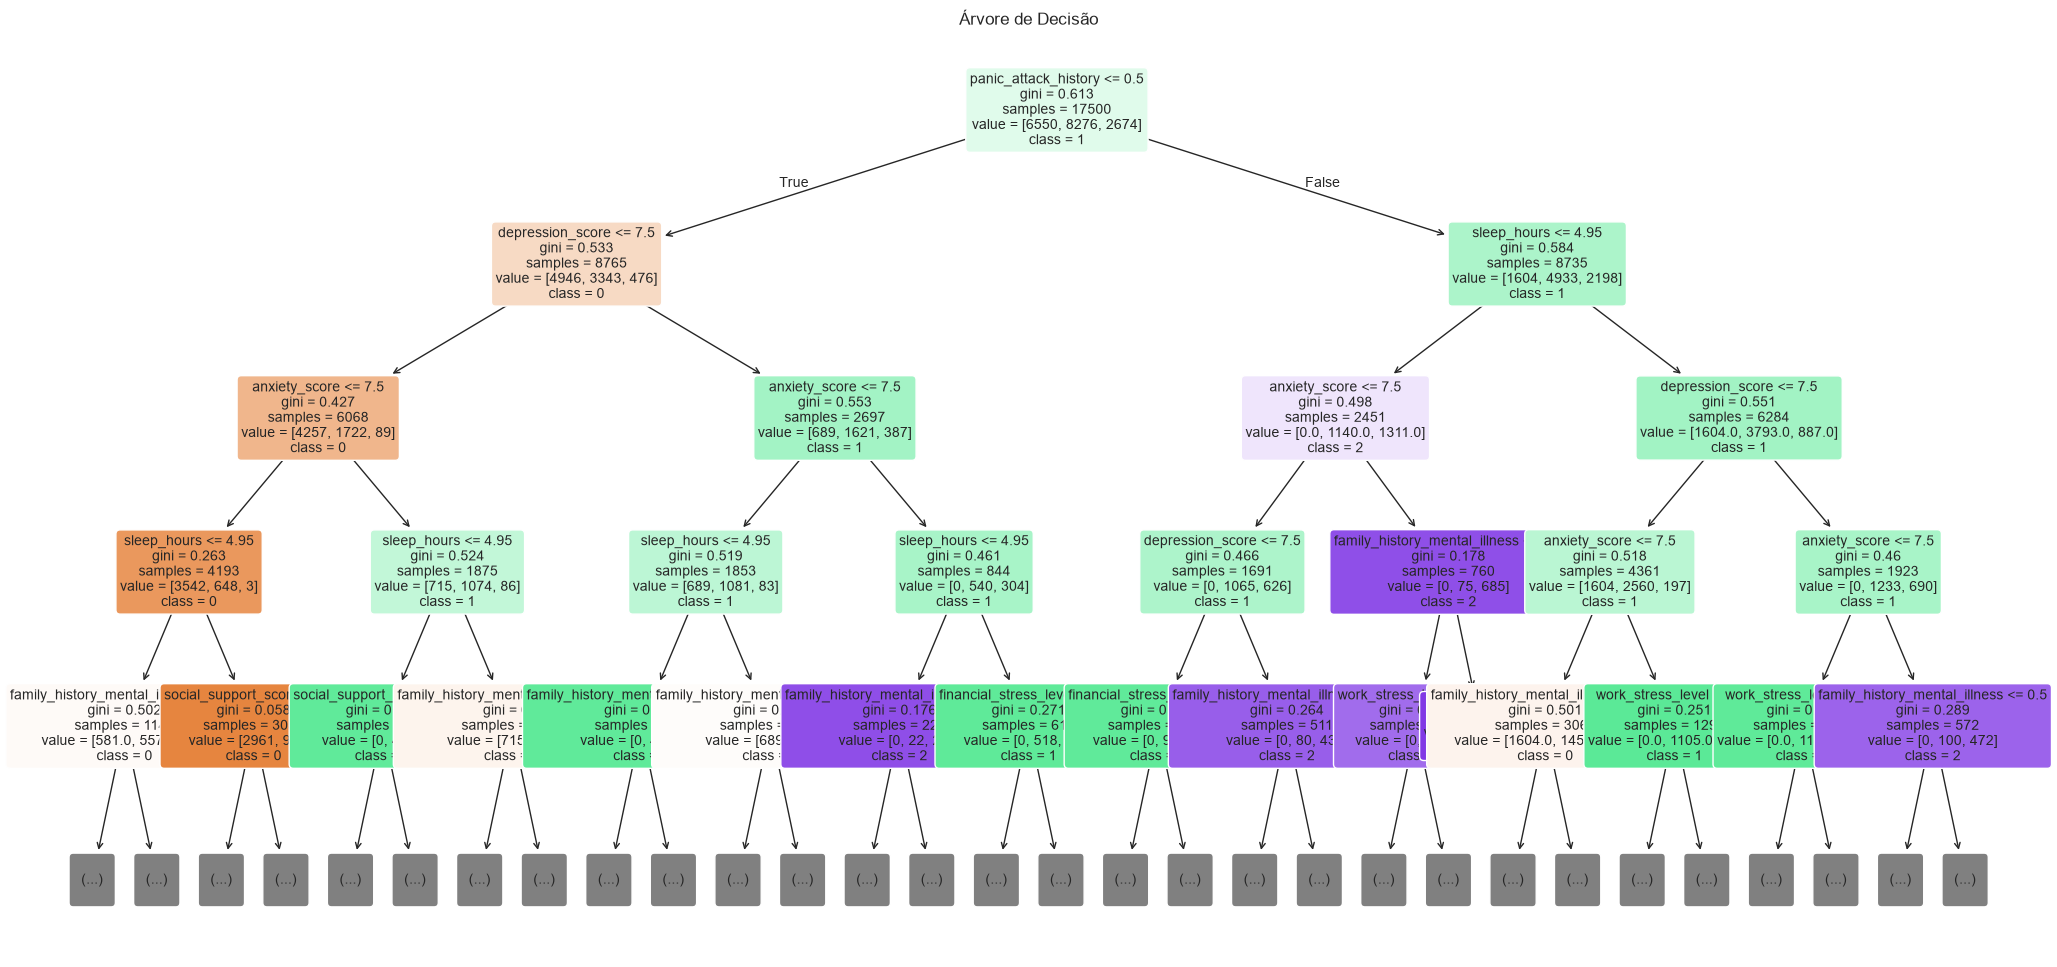

In [40]:
from sklearn.tree import plot_tree
class_names_str = [str(c) for c in modelo_dt.classes_]

plt.figure(figsize=(25, 12))

plot_tree(
    modelo_dt, 
    feature_names=X_train.columns.tolist(), 
    class_names=class_names_str,
    filled=True, 
    rounded=True, 
    fontsize=10,
    max_depth=4
)

plt.title("Árvore de Decisão")
plt.show()

=== Métricas de Desempenho - Random Forest ===
Acurácia:      0.9308
Precisão:      0.9343
Sensibilidade: 0.9308
F1-Score:      0.9277
AUC:           0.9849


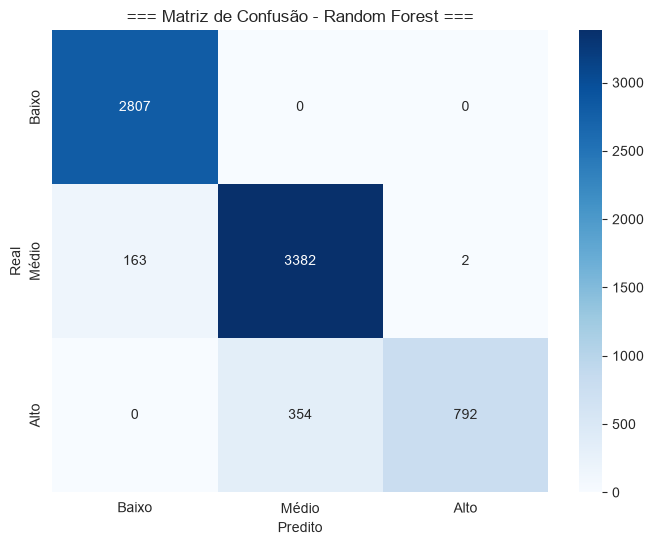

In [41]:
from sklearn.ensemble import RandomForestClassifier

modelo_rf = RandomForestClassifier(
    n_estimators=200,          
    max_depth=7,                
    min_samples_leaf=10,  
    min_samples_split=20,      
    random_state=777,
    n_jobs=-1                
)

modelo_rf.fit(X_train, y_train)

y_pred_rf = modelo_rf.predict(X_test)
y_probs_rf = modelo_rf.predict_proba(X_test)

acuracia_rf      = accuracy_score(y_test, y_pred_rf)
precisao_rf      = precision_score(y_test, y_pred_rf, average='weighted')
sensibilidade_rf = recall_score(y_test, y_pred_rf, average='weighted')
f1_rf            = f1_score(y_test, y_pred_rf, average='weighted')
auc_rf           = roc_auc_score(y_test, y_probs_rf, multi_class="ovr", average='weighted')

print("=== Métricas de Desempenho - Random Forest ===")
print(f"Acurácia:      {acuracia_rf:.4f}")
print(f"Precisão:      {precisao_rf:.4f}")
print(f"Sensibilidade: {sensibilidade_rf:.4f}")
print(f"F1-Score:      {f1_rf:.4f}")
print(f"AUC:           {auc_rf:.4f}")

cm_rf = confusion_matrix(y_test, y_pred_rf)
labels = ["Baixo", "Médio", "Alto"]

plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', 
            xticklabels=labels, yticklabels=labels)
plt.title('=== Matriz de Confusão - Random Forest ===')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.show()

=== Métricas de Desempenho - XGBoost ===
Acurácia:      0.9612
Precisão:      0.9622
Sensibilidade: 0.9612
F1-Score:      0.9609
AUC:           0.9879


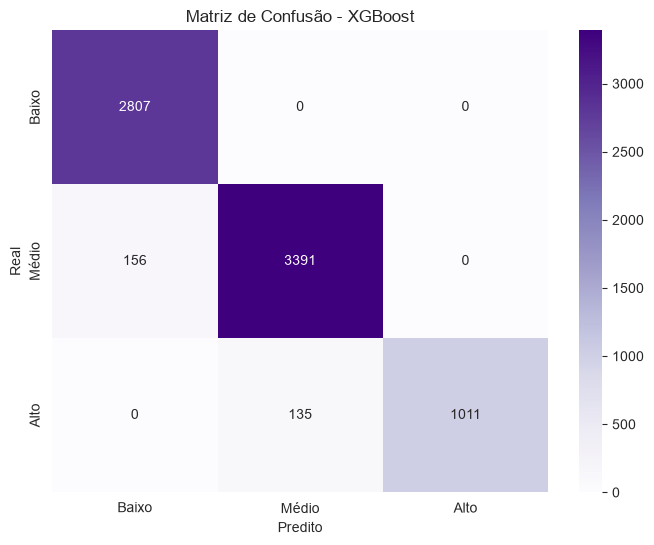

In [42]:
from xgboost import XGBClassifier

modelo_xgb = XGBClassifier(
    n_estimators=200,           
    max_depth=4,               
    learning_rate=0.05,         
    random_state=777,
    n_jobs=-1
)

modelo_xgb.fit(X_train, y_train)

y_pred_xgb = modelo_xgb.predict(X_test)
y_probs_xgb = modelo_xgb.predict_proba(X_test)

acuracia_xgb      = accuracy_score(y_test, y_pred_xgb)
precisao_xgb      = precision_score(y_test, y_pred_xgb, average='weighted')
sensibilidade_xgb = recall_score(y_test, y_pred_xgb, average='weighted')
f1_xgb            = f1_score(y_test, y_pred_xgb, average='weighted')
auc_xgb           = roc_auc_score(y_test, y_probs_xgb, multi_class='ovr', average='weighted')

print("=== Métricas de Desempenho - XGBoost ===")
print(f"Acurácia:      {acuracia_xgb:.4f}")
print(f"Precisão:      {precisao_xgb:.4f}")
print(f"Sensibilidade: {sensibilidade_xgb:.4f}")
print(f"F1-Score:      {f1_xgb:.4f}")
print(f"AUC:           {auc_xgb:.4f}")

cm_xgb = confusion_matrix(y_test, y_pred_xgb)
labels = ["Baixo", "Médio", "Alto"]

plt.figure(figsize=(8, 6))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Purples', 
            xticklabels=labels, yticklabels=labels)
plt.title('Matriz de Confusão - XGBoost')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.show()

Todos os modelos são bons ao analisar os resultados apresentados. Foi escolhido a árvore de decisão como modelo final devido ao fato de ser um modelo caixa branca e de ser menos custoso de treinar que os ensembles usados.  

In [ ]:
import numpy as np
from sklearn.metrics import roc_curve, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

classes  = modelo_dt.classes_.tolist()  
idx_high = classes.index(2) 

y_bin_high = (y_test == 2).astype(int)
probs_high = y_probs_dt[:, idx_high]

fpr, tpr, thresholds = roc_curve(y_bin_high, probs_high)
youden     = tpr - fpr
melhor_idx = np.argmax(youden)
best_thr   = thresholds[melhor_idx]

print(f"Melhor threshold para classe 2 (Alto Risco) via Youden: {best_thr:.4f}")

y_pred_thr = []
for prob_row in y_probs_dt:
    if prob_row[idx_high] >= best_thr:
        y_pred_thr.append(2)  
    else:
        probs_sem_high = prob_row.copy()
        probs_sem_high[idx_high] = -1
        y_pred_thr.append(classes[np.argmax(probs_sem_high)])

y_pred_thr = np.array(y_pred_thr)

acuracia_t      = accuracy_score(y_test, y_pred_thr)
precisao_t      = precision_score(y_test, y_pred_thr, average='weighted')
sensibilidade_t = recall_score(y_test, y_pred_thr, average='weighted')
f1_t            = f1_score(y_test, y_pred_thr, average='weighted')
auc_t           = roc_auc_score(y_test, y_probs_dt, multi_class='ovr', average='weighted')

print("\n=== Métricas com Threshold Otimizado para classe 2 (Alto Risco) ===")
print(f"Acurácia:      {acuracia_t:.4f}")
print(f"Precisão:      {precisao_t:.4f}")
print(f"Sensibilidade: {sensibilidade_t:.4f}")
print(f"F1-Score:      {f1_t:.4f}")
print(f"AUC Total:     {auc_t:.4f}")

2
Melhor threshold para classe 2 (Alto Risco) via Youden: 0.2414

=== Métricas com Threshold Otimizado para classe 2 (Alto Risco) ===
Acurácia:      0.9607
Precisão:      0.9612
Sensibilidade: 0.9607
F1-Score:      0.9604
AUC Total:     0.9901
